PCA Python Implementation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

This section demonstrates a step-by-step implementation of Principal Component Analysis (PCA) using basic NumPy operations. It covers mean centering, covariance matrix calculation, eigenvalue decomposition, and data projection onto the principal component.

In [4]:
# Dataset
X = np.array([
    [2, 1],
    [4, 3],
    [6, 5],
    [8, 7]
])

First, we define a simple 2D dataset `X` that we will use to illustrate the PCA process.

In [5]:
print("Original Data:")
print(X)

Original Data:
[[2 1]
 [4 3]
 [6 5]
 [8 7]]


In [6]:
# Step 1: Mean Centering
X_centered = X - np.mean(X, axis=0)

print("\nCentered Data:")
print(X_centered)


Centered Data:
[[-3. -3.]
 [-1. -1.]
 [ 1.  1.]
 [ 3.  3.]]


Before performing PCA, it's crucial to center the data by subtracting the mean of each feature (column) from the respective feature values. This ensures that the first principal component explains the maximum variance.

In [7]:
# Step 2: Covariance Matrix
cov_matrix = np.cov(X_centered.T, bias=True)

print("\nCovariance Matrix:")
print(cov_matrix)


Covariance Matrix:
[[5. 5.]
 [5. 5.]]


The covariance matrix describes the relationships between the different dimensions (features) of the centered data. A positive covariance indicates that features tend to increase or decrease together, while a negative covariance indicates an inverse relationship. A covariance of zero suggests no linear relationship.

In [8]:
# Step 3: Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


Next, we compute the eigenvalues and eigenvectors of the covariance matrix. Eigenvectors represent the principal components (directions of maximum variance), and eigenvalues represent the magnitude of variance along those directions.

In [9]:
print("\nEigenvalues:")
print(eigenvalues)


Eigenvalues:
[1.0000000e+01 8.8817842e-16]


In [10]:
print("\nEigenvectors:")
print(eigenvectors)


Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [11]:
# Step 4: Sort by Eigenvalue
idx = np.argsort(eigenvalues)[::-1]

To identify the most significant principal components, we sort the eigenvalues in descending order. The corresponding eigenvectors are also reordered accordingly.

In [12]:
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [14]:
print("\nSorted Eigenvalues:")
print(eigenvalues)

print("\nSorted Eigenvectors:")
print(eigenvectors)


Sorted Eigenvalues:
[1.0000000e+01 8.8817842e-16]

Sorted Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [13]:
# Step 5: Select First Principal Component
PC1 = eigenvectors[:, 0]

print("\nFirst Principal Component:")
print(PC1)


First Principal Component:
[0.70710678 0.70710678]


We select the eigenvector corresponding to the largest eigenvalue. This is our first principal component, which captures the most variance in the data.

In [ ]:
# Step 6: Project Data
X_pca = X_centered @ PC1

print("\nProjected Data:")
print(X_pca)


Projected Data:
[-4.24264069 -1.41421356  1.41421356  4.24264069]


Finally, we project the mean-centered data onto the selected principal component to obtain the lower-dimensional representation of the data. This `X_pca` represents the original data transformed into the principal component space.

PCA using Scikit-learn

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

This section demonstrates how to perform PCA using Scikit-learn's `PCA` class, which simplifies the process significantly. It also includes steps to generate sample data and visualize the results.

Create rendom data and plot the points

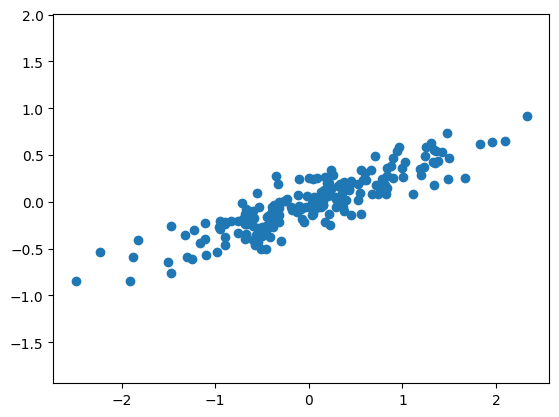

In [15]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1])
plt.axis('equal');

We generate a 2D random dataset to visualize how PCA works. The `plt.scatter` function plots these points, and `plt.axis('equal')` ensures that the aspect ratio of the plot is maintained.

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

PCA(n_components=2)

Here, we initialize a `PCA` object and specify `n_components=2`, meaning we want to find two principal components. We then fit the PCA model to our data `X`, which calculates the principal components and their explained variances.

In [18]:
print(pca.components_)

[[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]


The `pca.components_` attribute stores the principal components themselves. Each row represents a principal component, which is a vector in the original feature space. These vectors indicate the directions of maximum variance in the data.

In [17]:
print(pca.explained_variance_) # This array shows the variance explained by each principal component.

[0.7625315 0.0184779]


To see what these numbers mean, let's visualize them as vectors over the input data, using the components to define the direction of the vector and the explained variance to define the squared length of the vector (see the following figure):

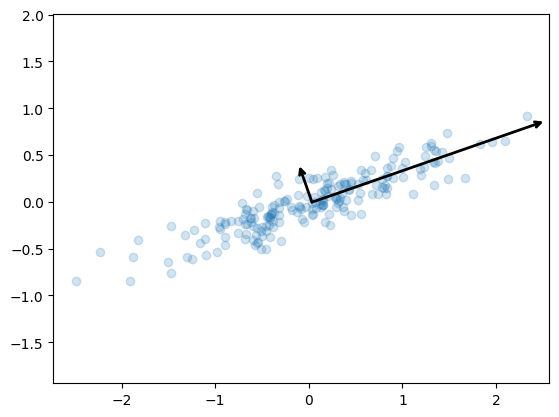

In [19]:
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->', linewidth=2,
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

This code block defines a helper function `draw_vector` to visualize vectors. It then uses this function to plot the original data points and overlay the principal component vectors. The length of each vector is scaled by its corresponding explained variance to visually represent its importance.

These vectors represent the principal axes of the data, and the length of each vector is an indication of how "important" that axis is in describing the distribution of the data—more precisely, it is a measure of the variance of the data when projected onto that axis. The projection of each data point onto the principal axes are the principal components of the data.

PCA as Dimensionality Reduction

Using PCA for dimensionality reduction involves zeroing out one or more of the smallest principal components, resulting in a lower-dimensional projection of the data that preserves the maximal data variance.

Here is an example of using PCA as a dimensionality reduction transform:

In [ ]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape:   ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:    (200, 2)
transformed shape: (200, 1)


To demonstrate PCA as a dimensionality reduction technique, we apply PCA with `n_components=1`. This projects the 2D data onto a single principal component, effectively reducing its dimensionality. The original and transformed shapes are printed to show this reduction.

The transformed data has been reduced to a single dimension. To understand the effect of this dimensionality reduction, we can perform the inverse transform of this reduced data and plot it along with the original data (see the following figure):

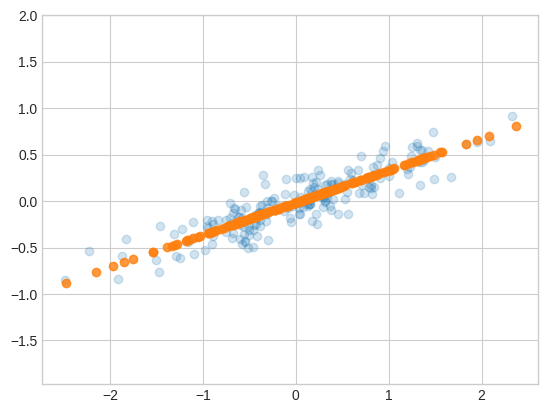

In [ ]:
X_new = pca.inverse_transform(X_pca)
plt.scatter(X[:, 0], X[:, 1], alpha=0.2)
plt.scatter(X_new[:, 0], X_new[:, 1], alpha=0.8)
plt.axis('equal');

After reducing the data to one dimension, we can use `pca.inverse_transform` to project the data back into the original 2D space. This visualization helps understand what information is retained and lost during dimensionality reduction. The light points are original, dark points are projected.

The light points are the original data, while the dark points are the projected version. This makes clear what a PCA dimensionality reduction means: the information along the least important principal axis or axes is removed, leaving only the component(s) of the data with the highest variance. The fraction of variance that is cut out (proportional to the spread of points about the line formed in the preceding figure) is roughly a measure of how much "information" is discarded in this reduction of dimensionality.

This reduced-dimension dataset is in some senses "good enough" to encode the most important relationships between the points: despite reducing the number of data features by 50%, the overall relationships between the data points are mostly preserved.

PCA for Visualization: Handwritten Digits

In [20]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

We load the `digits` dataset, which consists of 8x8 pixel images of handwritten digits. We then print its shape to see that each image is represented by 64 features (pixels).

The digits dataset consists of 8 × 8–pixel images, meaning that they are 64-dimensional. To gain some intuition into the relationships between these points, we can use PCA to project them into a more manageable number of dimensions, say two:

In [21]:
pca = PCA(2)  # project from 64 to 2 dimensions
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


Here, PCA is applied to the 64-dimensional `digits.data` to project it into a 2-dimensional space. This allows for easy visualization of the high-dimensional data while retaining as much variance as possible.

/tmp/ipykernel_4150/2943749715.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('rainbow', 10))


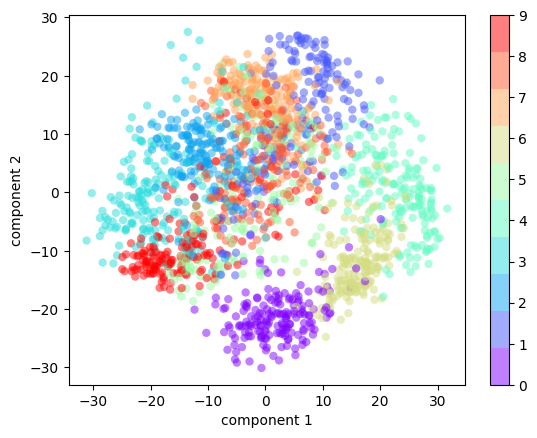

In [22]:
plt.scatter(projected[:, 0], projected[:, 1],
            c=digits.target, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('rainbow', 10))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.colorbar();

This scatter plot visualizes the 2-dimensional projection of the digits data. Each point represents a digit, colored according to its original label (`digits.target`). This helps to observe how well different digits are separated in the reduced dimension space.

The full data is a 64-dimensional point cloud, and these points are the projection of each data point along the directions with the largest variance. Essentially, we have found the optimal stretch and rotation in 64-dimensional space that allows us to see the layout of the data in two dimensions, and we have done this in an unsupervised manner—that is, without reference to the labels.

What Do the Components Mean?

We can go a bit further here, and begin to ask what the reduced dimensions mean. This meaning can be understood in terms of combinations of basis vectors. For example, each image in the training set is defined by a collection of 64 pixel values, which we will call the vector  𝑥 :

𝑥=[𝑥1,𝑥2,𝑥3⋯𝑥64]

One way we can think about this is in terms of a pixel basis. That is, to construct the image, we multiply each element of the vector by the pixel it describes, and then add the results together to build the image:

image(𝑥)=𝑥1⋅(pixel 1)+𝑥2⋅(pixel 2)+𝑥3⋅(pixel 3)⋯𝑥64⋅(pixel 64)

One way we might imagine reducing the dimensionality of this data is to zero out all but a few of these basis vectors. For example, if we use only the first eight pixels, we get an eight-dimensional projection of the data (the following figure). However, it is not very reflective of the whole image: we've thrown out nearly 90% of the pixels!


The upper row of panels shows the individual pixels, and the lower row shows the cumulative contribution of these pixels to the construction of the image. Using only eight of the pixel-basis components, we can only construct a small portion of the 64-pixel image. Were we to continue this sequence and use all 64 pixels, we would recover the original image.

But the pixel-wise representation is not the only choice of basis. We can also use other basis functions, which each contain some predefined contribution from each pixel, and write something like:

𝑖𝑚𝑎𝑔𝑒(𝑥)=mean+𝑥1⋅(basis 1)+𝑥2⋅(basis 2)+𝑥3⋅(basis 3)⋯

PCA can be thought of as a process of choosing optimal basis functions, such that adding together just the first few of them is enough to suitably reconstruct the bulk of the elements in the dataset. The principal components, which act as the low-dimensional representation of our data, are simply the coefficients that multiply each of the elements in this series. the following figure shows a similar depiction of reconstructing the same digit using the mean plus the first eight PCA basis functions.


Unlike the pixel basis, the PCA basis allows us to recover the salient features of the input image with just a mean, plus eight components! The amount of each pixel in each component is the corollary of the orientation of the vector in our two-dimensional example. This is the sense in which PCA provides a low-dimensional representation of the data: it discovers a set of basis functions that are more efficient than the native pixel basis of the input data.

Choosing the Number of Components

A vital part of using PCA in practice is the ability to estimate how many components are needed to describe the data. This can be determined by looking at the cumulative explained variance ratio as a function of the number of components (see the following figure):

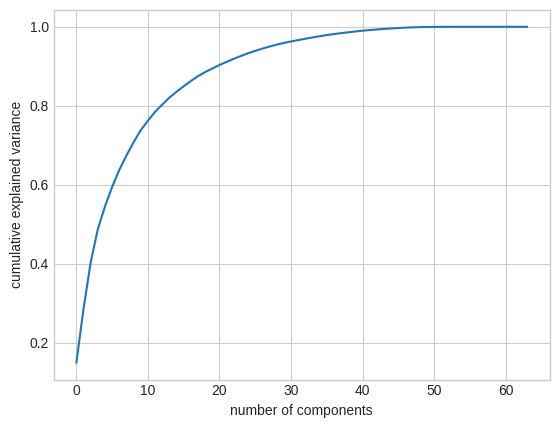

In [ ]:
pca = PCA().fit(digits.data)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

This plot shows the cumulative explained variance ratio as a function of the number of principal components. It helps determine how many components are needed to capture a certain percentage of the total variance in the data. For instance, you can see how many components are required to explain 90% of the variance.

This curve quantifies how much of the total, 64-dimensional variance is contained within the first  𝑁  components. For example, we see that with the digits data the first 10 components contain approximately 75% of the variance, while you need around 50 components to describe close to 100% of the variance.

This tells us that our 2-dimensional projection loses a lot of information (as measured by the explained variance) and that we'd need about 20 components to retain 90% of the variance. Looking at this plot for a high-dimensional dataset can help you understand the level of redundancy present in its features.

PCA as Noise Filtering

PCA can also be used as a filtering approach for noisy data. The idea is this: any components with variance much larger than the effect of the noise should be relatively unaffected by the noise. So, if you reconstruct the data using just the largest subset of principal components, you should be preferentially keeping the signal and throwing out the noise.

Let's see how this looks with the digits data. First we will plot several of the input noise-free input samples (the following figure):

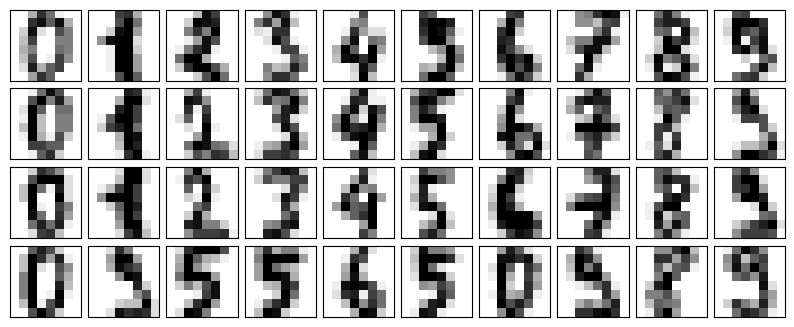

In [23]:
def plot_digits(data):
    fig, axes = plt.subplots(4, 10, figsize=(10, 4),
                             subplot_kw={'xticks':[], 'yticks':[]},
                             gridspec_kw=dict(hspace=0.1, wspace=0.1))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i].reshape(8, 8),
                  cmap='binary', interpolation='nearest',
                  clim=(0, 16))
plot_digits(digits.data)

This code block defines a utility function `plot_digits` to display 8x8 pixel images. It is then used to show a subset of the original, noise-free handwritten digit images from the `digits` dataset.

Now let's add some random noise to create a noisy dataset, and replot it (the following figure):

In [ ]:
rng = np.random.default_rng(42)
rng.normal(10, 2)

10.609434159508863

This line initializes a random number generator and generates a single random number from a normal distribution. While this cell is a standalone example, the next cell uses `rng` to add noise to the dataset.

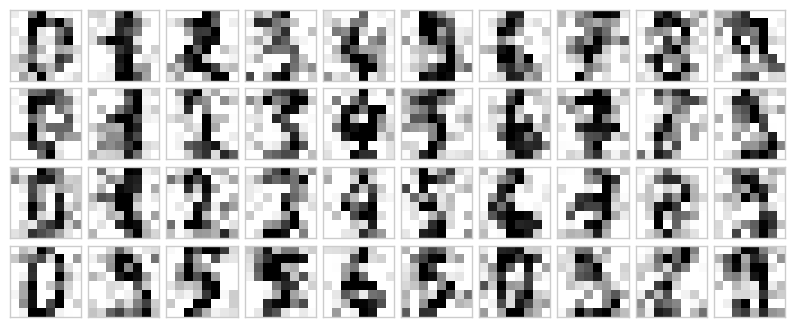

In [ ]:
rng = np.random.default_rng(42)
noisy = rng.normal(digits.data, 4)
plot_digits(noisy)

Here, random noise sampled from a normal distribution is added to the original `digits.data`. The `plot_digits` function is then used to visualize these noisy digits, highlighting the impact of the added noise.

The visualization makes the presence of this random noise clear. Let's train a PCA model on the noisy data, requesting that the projection preserve 50% of the variance:

In [ ]:
pca = PCA(0.50).fit(noisy)
pca.n_components_

np.int64(12)

A PCA model is trained on the `noisy` data, with a parameter `0.50` indicating that we want to retain principal components that cumulatively explain 50% of the variance. `pca.n_components_` will show the actual number of components selected to achieve this.

Here 50% of the variance amounts to 12 principal components, out of the 64 original features. Now we compute these components, and then use the inverse of the transform to reconstruct the filtered digits; the following figure shows the result:

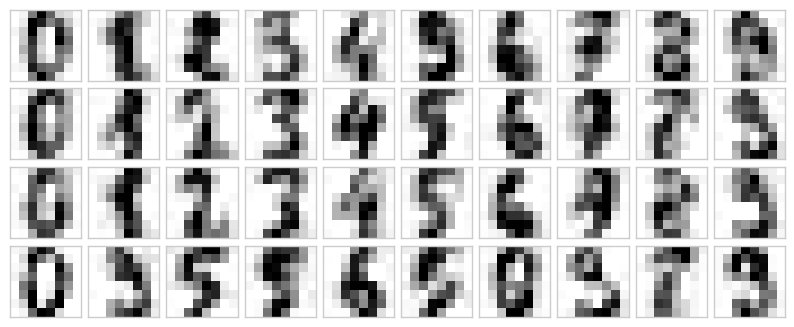

In [ ]:
components = pca.transform(noisy)
filtered = pca.inverse_transform(components)
plot_digits(filtered)

The noisy data is transformed into the principal component space, and then inverse transformed back to the original feature space using only the selected components (explaining 50% variance). This effectively filters out some of the noise, as the less important components (often associated with noise) are discarded. The filtered digits are then plotted.

This signal preserving/noise filtering property makes PCA a very useful feature selection routine—for example, rather than training a classifier on very high-dimensional data, you might instead train the classifier on the lower-dimensional principal component representation, which will automatically serve to filter out random noise in the inputs.